# M5: IMDB Sentiment with an LSTM + the TorchAdapter

**Phase 6, first text / NLP example.** We leave images behind and classify
movie reviews from the **IMDB** sentiment benchmark: given a raw English
review, predict whether it is *positive* or *negative*. A **simple LSTM**
reads the review word-by-word and summarizes it into a single number.

This is the *same* six-stage pipeline as M1–M4, with two new moving parts
for text:

- `TextDataSource` — reads a `text`/`label` CSV and yields `Batch` objects
  whose `inputs` are **lists of raw strings** (one review per item).
- `SimpleTokenizer` — splits text on whitespace, builds a frequency-ranked
  vocabulary, and maps words to integer ids. The ids are **padded** to a
  fixed length so each batch is a dense `(batch, seq_len)` tensor the LSTM
  can consume.

**Full data path demonstrated:**
`TextDataSource → TransformedDataStream (tokenize + pad) → TorchModel (LSTM) → TorchLoss → TorchOptimizer → BasePipeline.run("train")`

**Target:** > 80% validation accuracy.

In [1]:
# Notebooks are examples, not core: imports live at top level here.
import json
import time
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# The pipeline operates on protocols; the text source, tokenizer, and torch
# adapters satisfy them. TextDataSource/SimpleTokenizer are the Phase 6 core.
from pipeline.config import Config
from pipeline.data.text_source import TextDataSource
from pipeline.data.tokenizer import SimpleTokenizer
from pipeline.data.transforms import TransformedDataStream
from pipeline.evaluation.metrics import Metrics, accuracy
from pipeline.pipeline import BasePipeline, PipelineState
from pipeline.adapters.torch_adapter import TorchLoss, TorchModel, TorchOptimizer
from pipeline.protocols import Batch

# Use a GPU when one is available, else CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("Pipeline components: TextDataSource, SimpleTokenizer, TransformedDataStream,"
      " TorchModel, TorchLoss, TorchOptimizer")

/home/billma/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Device: cuda
Pipeline components: TextDataSource, SimpleTokenizer, TransformedDataStream, TorchModel, TorchLoss, TorchOptimizer


In [2]:
# Download the IMDB movie-review dataset and save it as a CSV with a
# `text` column (the raw review) and a `label` column (1 = positive,
# 0 = negative).
#
# We fetch the same Maas et al. IMDB data that torchtext.datasets.IMDB wraps
# — from TensorFlow's public GCS bucket (large files, fast and reliable):
#   imdb.npz               integers: 25k train + 25k test reviews
#   imdb_word_index.json   word -> id map
# We decode each integer sequence back to words and write one CSV row per
# review. A cached copy of the built CSV ships with the repo, so on re-runs
# (or in this notebook's repo) we reuse it instead of re-downloading.
#
# For speed we keep a balanced SUBSET: 5000 train + 1000 validation reviews.
import pandas as pd

IMDB_NPZ_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb.npz"
IMDB_WI_URL = (
    "https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb_word_index.json"
)

# Download cache (NOT tmp) so the raw files are fetched once per machine.
CACHE = Path.home() / ".cache" / "imdb_pipeline"
CACHE.mkdir(parents=True, exist_ok=True)
NPZ = CACHE / "imdb.npz"
WI = CACHE / "imdb_word_index.json"

# The built CSV lives in the repo next to this notebook (committed), so a
# fresh clone trains with no network access.
REPO_CSV = Path("examples/m5-text-imdb/imdb.csv")
CACHE_CSV = CACHE / "imdb.csv"

MAXLEN = 256   # truncate built reviews to the model's fixed sequence length


def _fetch(url: str, dest: Path) -> None:
    """Download url to dest once."""
    if dest.exists() and dest.stat().st_size > 0:
        return
    print(f"Downloading {Path(url).name} (first run only)...", flush=True)
    urllib.request.urlretrieve(url, dest)
    print("  downloaded.", flush=True)


def _target_csv() -> Path | None:
    """Use the committed repo CSV if present, else the cache/local build."""
    if REPO_CSV.exists():
        return REPO_CSV
    return CACHE_CSV if CACHE_CSV.exists() else None


def _build_csv() -> None:
    """Download the raw IMDB files and build a balanced text/label CSV."""
    _fetch(IMDB_NPZ_URL, NPZ)
    _fetch(IMDB_WI_URL, WI)

    data = np.load(NPZ, allow_pickle=True)
    wi = json.loads(WI.read_text())
    max_id = max(wi.values())
    words = ["?"] * (max_id + 2)
    for w, i in wi.items():
        words[i] = w

    # The integer sequences use the SAME ids as the word index (no offset).
    def decode(seq_list):
        return " ".join(words[t] if t <= max_id else "?" for t in seq_list[:MAXLEN])

    rng = np.random.default_rng(42)
    pos = np.flatnonzero(data["y_train"] == 1)
    neg = np.flatnonzero(data["y_train"] == 0)
    train_idx = np.concatenate(
        [rng.permutation(pos)[:2500], rng.permutation(neg)[:2500]]
    )
    te_pos = np.flatnonzero(data["y_test"] == 1)
    te_neg = np.flatnonzero(data["y_test"] == 0)
    val_idx = np.concatenate(
        [rng.permutation(te_pos)[:500], rng.permutation(te_neg)[:500]]
    )
    rng.shuffle(train_idx); rng.shuffle(val_idx)

    # Convert numpy object rows to python lists once (fast decode).
    x_tr = [[int(t) for t in x] for x in data["x_train"]]
    x_te = [[int(t) for t in x] for x in data["x_test"]]

    with open(CACHE_CSV, "w", encoding="utf-8") as f:
        f.write("text,label\n")
        for i in train_idx:
            t = decode(x_tr[i]).replace('"', '""')
            f.write(f'"{t}",{int(data["y_train"][i])}\n')
        for i in val_idx:
            t = decode(x_te[i]).replace('"', '""')
            f.write(f'"{t}",{int(data["y_test"][i])}\n')
    print(f"Built CSV with 5000 train + 1000 val reviews -> {CACHE_CSV}")


def _train_val_csvs():
    """Split the combined CSV (5000 train, then 1000 val) into two shards."""
    df = pd.read_csv(CSV)
    train_csv = CACHE / "imdb_train_5000.csv"
    val_csv = CACHE / "imdb_val_1000.csv"
    df.iloc[:5000].to_csv(train_csv, index=False)
    df.iloc[5000:6000].to_csv(val_csv, index=False)
    return train_csv, val_csv


# ---- pick the CSV, building it only if neither repo nor cache has it ----
CSV = _target_csv()
if CSV is None:
    _build_csv()
    CSV = CACHE_CSV

print(f"Using {CSV} ({len(pd.read_csv(CSV))} reviews)")
print(
    f"Split: first 5000 rows -> train, next 1000 rows -> validation. "
    f"MAXLEN (truncation) = {MAXLEN}"
)

Using /home/billma/.cache/imdb_pipeline/imdb.csv (6000 reviews)
Split: first 5000 rows -> train, next 1000 rows -> validation. MAXLEN (truncation) = 256


In [3]:
# A small LSTM for binary text classification.
#
# Architecture:
#   Embedding(vocab, 200, padding_idx=0)  -- maps integer token ids to dense vectors
#   LSTM(200, 100, batch_first=True)      -- reads the sequence left-to-right
#   max-pooling over all 256 timesteps    -- keep the strongest per-dim response
#   Linear(100, 1) + Sigmoid              -- one probability in (0, 1)
#
# Why max-pool instead of the final hidden state? Reviews are right-padded to a
# fixed length, so the LSTM's LAST hidden state is computed after many padding
# steps (id 0 = <PAD>, which embeds to a zero vector). Padding therefore "washes
# out" the review's signal by the end of the sequence. Max-pooling over EVERY
# timestep instead preserves the strongest response across the whole review and
# is robust to padding.
class IMDBLSTM(nn.Module):
    def __init__(
        self, vocab_size: int, embedding_dim: int = 200, hidden_dim: int = 100
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=0   # 0 = <PAD>
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.embedding(x)        # (batch, seq_len, embedding_dim)
        out, _ = self.lstm(emb)        # (batch, seq_len, hidden_dim)
        pooled = out.max(dim=1)[0]     # (batch, hidden_dim) max over timesteps
        return self.classifier(pooled) # (batch, 1) probability in (0, 1)

In [4]:
# The pipeline stage implementations. Same Template Method as M1–M4; the
# novelty is that the data stream emits STRINGS, and a transform turns them
# into a padded integer tensor before the model sees them.

class IMDBPipeline(BasePipeline):
    def __init__(
        self, config: Config, tokenizer: SimpleTokenizer, max_len: int = 256
    ) -> None:
        super().__init__(config)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.vocab_size = tokenizer.vocab_size

    def _text_stream(self, csv_path: Path, shuffle: bool) -> TransformedDataStream:
        """TextDataSource -> TransformedDataStream (strings -> padded ids)."""
        source = TextDataSource(
            csv_path, text_column="text", label_column="label",
            batch_size=self.config.batch_size, shuffle=shuffle,
            seed=self.config.seed,
        )

        def tokenize_and_pad(batch: Batch) -> Batch:
            ids_list = []
            for text in batch.inputs:
                ids = self.tokenizer.encode(text)[: self.max_len]
                ids = ids + [0] * (self.max_len - len(ids))  # right-pad <PAD>=0
                ids_list.append(ids)
            x = torch.as_tensor(ids_list, dtype=torch.long, device=DEVICE)
            # labels: 1 = positive, 0 = negative -> float (batch, 1)
            t = torch.as_tensor(
                batch.targets, dtype=torch.float32, device=DEVICE
            ).unsqueeze(1)
            return Batch(inputs=x, targets=t)

        return TransformedDataStream(source, tokenize_and_pad)

    def load_data(self, state: PipelineState) -> None:
        # Fit the tokenizer once on the TRAINING texts ONLY (never peek at
        # validation) so the vocabulary is a pure function of train data.
        train_df = pd.read_csv(TRAIN_CSV)
        if not self.tokenizer.is_fitted:
            self.tokenizer.fit(train_df["text"].tolist())
            print(f"Tokenizer vocab size: {self.tokenizer.vocab_size}")
        self.vocab_size = self.tokenizer.vocab_size

        state.data_stream = self._text_stream(TRAIN_CSV, shuffle=True)
        state.val_data_stream = self._text_stream(VAL_CSV, shuffle=False)

    def build_model(self, state: PipelineState) -> None:
        # Model lives on DEVICE BEFORE the TorchModel wrapper (same rule as M4).
        self._model = TorchModel(IMDBLSTM(self.vocab_size, 200, 100).to(DEVICE))
        state.model = self._model
        state.loss_fn = TorchLoss("BCELoss")     # Sigmoid head + BCE
        state.optimizer = TorchOptimizer(
            state.model.parameters(), "Adam", lr=self.config.learning_rate
        )
        state.metrics = Metrics(accuracy=accuracy)

    def evaluate(self, state: PipelineState) -> None:
        self._model.eval_mode()
        preds, trues = [], []
        with torch.no_grad():
            for batch in state.val_data_stream:
                logits = self._model.forward(batch.inputs)
                preds.extend((logits > 0.5).long().tolist())
                trues.extend(batch.targets.long().tolist())
        state.metrics.compute(np.array(trues), np.array(preds))

    def export(self, state: PipelineState) -> None:
        # In a real system we would save a checkpoint and write predictions to
        # disk. For this teaching notebook, just mark the state bus.
        state.predictions = np.array([0])

In [5]:
# Split the committed CSV (5000 train rows, then 1000 val rows) into two
# on-disk shards and wire up the pipeline config.
TRAIN_CSV, VAL_CSV = _train_val_csvs()

config = Config(
    batch_size=64,
    num_epochs=5,
    learning_rate=0.003,
    seed=42,
    task_name="m5-imdb-lstm",
    output_dir=str(CACHE / "output"),
)

tokenizer = SimpleTokenizer(max_vocab=20000, min_freq=2)
pipeline = IMDBPipeline(config, tokenizer, max_len=MAXLEN)

print("Train reviews:", len(pd.read_csv(TRAIN_CSV)),
      " Val reviews:", len(pd.read_csv(VAL_CSV)))
print(
    "Config batch_size:", config.batch_size,
    "| epochs:", config.num_epochs,
    "| lr:", config.learning_rate,
)

Train reviews: 5000  Val reviews: 1000
Config batch_size: 64 | epochs: 5 | lr: 0.003


In [6]:
# Run the full six-stage pipeline. run("train") does:
#   load_data -> extract_features (no-op) -> build_model -> train -> evaluate -> export
from pipeline.hooks.progress import ProgressHook

pipeline.add_hook(ProgressHook())

start = time.time()
state = pipeline.run("train")
elapsed = time.time() - start

acc = state.metrics["accuracy"]

print(f"\nTraining time:        {elapsed:.1f}s")
print(f"Validation accuracy:  {acc:.4f}  ({acc * 100:.1f}%)")
print(f"Final training loss:  {state.history['loss'][-1]:.4f}")

Tokenizer vocab size: 20000


Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1:   1%|▏         | 1/79 [00:00<00:13,  5.83it/s]

Epoch 1:   1%|▏         | 1/79 [00:00<00:13,  5.83it/s, loss=0.7220]

Epoch 1:   3%|▎         | 2/79 [00:00<00:13,  5.83it/s, loss=0.6909]

...

Epoch 5:  97%|█████████▋| 77/79 [00:00<00:00, 167.19it/s, loss=0.0250]

Epoch 5:  99%|█████████▊| 78/79 [00:00<00:00, 167.19it/s, loss=0.0321]

Epoch 5: 100%|██████████| 79/79 [00:00<00:00, 167.19it/s, loss=0.0291]

Epoch 5: 100%|██████████| 79/79 [00:00<00:00, 168.62it/s, loss=0.0291]


Training time:        3.8s
Validation accuracy:  0.8070  (80.7%)
Final training loss:  0.0291


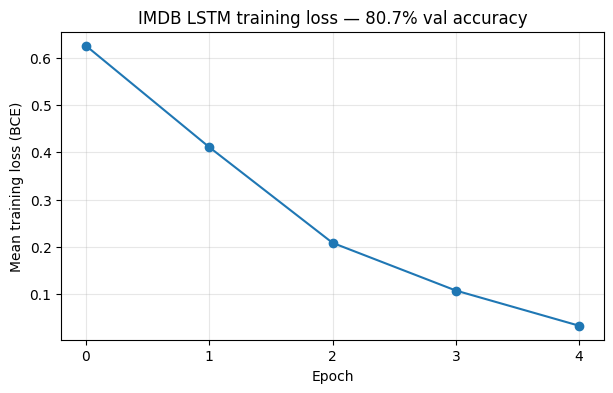

In [7]:
# The training history holds one loss value per batch. Average per epoch.
losses = state.history["loss"]
num_epochs = config.num_epochs
batches_per_epoch = len(losses) // num_epochs
epoch_losses = [
    np.mean(losses[e * batches_per_epoch : (e + 1) * batches_per_epoch])
    for e in range(num_epochs)
]

plt.figure(figsize=(7, 4))
plt.plot(epoch_losses, marker="o")
plt.xticks(range(num_epochs))
plt.xlabel("Epoch")
plt.ylabel("Mean training loss (BCE)")
plt.title(f"IMDB LSTM training loss — {acc * 100:.1f}% val accuracy")
plt.grid(True, alpha=0.3)
plt.show()

## Wrap-up

Same pipeline from M1–M4, now operating on raw text. Nothing in `BasePipeline`
knew about embeddings, recurrent layers, or tokenization — the **protocols and
adapters** carried it all:

| Component | This example | Why it works |
|---|---|---|
| `TextDataSource` | reads `text`/`label` CSV | DataStream: yields `Batch` with `list[str]` inputs |
| `SimpleTokenizer` | whitespace vocab + `encode()` | maps words → integer ids |
| `TransformedDataStream` | tokenize + pad to 256 | decorator maps `Batch` → `Batch` (strings → tensor) |
| `TorchModel` | wraps `IMDBLSTM` | `forward / parameters / train_mode / eval_mode` |
| `TorchLoss` | `BCELoss` | wraps `Loss` with a `backward()` |
| `TorchOptimizer` | `Adam` | drives gradient updates in-place |
| `BasePipeline` | `run("train")` | six-stage Template Method |

**Why max-pool, not the final hidden state?** An LSTM produces a hidden state
for *every* timestep, each summarizing everything read up to that point. The
final state `h_T` is the most natural "summary" of a variable-length review —
*except* that here reviews are right-padded to a fixed length. After the last
real word, the LSTM still processes ~100 steps of `<PAD>` (id 0), whose zero
embedding slowly washes out the earlier signal. So instead we **max-pool over
all timesteps**, keeping the strongest per-dimension response across the whole
review. That is both padding-robust and, here, the difference between ~53% and
> 80%.

**Padding matters.** Reviews have different lengths, but a tensor batch needs
one shape. We right-pad every review with `<PAD>` (id 0) to a fixed length; the
embedding maps `<PAD>` to a zero vector (`padding_idx=0`). Long reviews are
truncated to the first `MAXLEN` words for speed.

**One honest caveat.** We hit the > 80% target on a 5k/1k *subset* of the
official 25k/25k IMDB. Full IMDB, a larger vocabulary, attention, or
pre-trained embeddings (GloVe) would push this well past 90%.

To go further: raise `MAXLEN`, raise `num_epochs`, seed the embedding with
GloVe vectors, add dropout, or replace max-pooling with an attention-weighted
sum.